# 🏀 Predicting NCAA March Madness Winners with Machine Learning
### A Beginner's Guide to Prediction Modeling in Python

---

**Welcome!** In this tutorial, we're going to build a machine learning model that predicts whether a college basketball team will make it deep into the NCAA Tournament — using nothing but their regular season stats.

By the end of this notebook you'll understand:
- What machine learning *actually* is (in plain English)
- How to explore and clean real data using Python
- How to build two different prediction models
- How to evaluate whether your model is actually good

**No math degree required.** We'll explain everything as we go.

---

## 🧠 First: What is Machine Learning?

Imagine you're trying to predict who will win March Madness. You might look at things like:
- How many games did they win this season?
- Do they shoot well from the field?
- How good is their defense?

Machine learning does the same thing — but instead of you using your gut, **you feed data into a computer and use a prediction model to identify relationships in the data**.

> **The key idea:** Give the model inputs (team stats) → it learns patterns → it predicts an output (win or lose)

This is called **supervised learning** — we "supervise" the model by telling it the right answers during training, and then it generalizes to make predictions on new data.

---

## 📦 Step 1: Import Our Tools

Python doesn't come with machine learning built-in — we use **libraries** (pre-built toolkits). Think of these like apps on your phone.

Here's what each library does:
- **pandas** — works with data tables (like Excel, but in Python)
- **numpy** — fast math operations
- **matplotlib / seaborn** — makes charts and graphs
- **scikit-learn** — the machine learning toolkit

In [1]:
# Import our libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

# Make our charts look nice
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ All libraries loaded successfully!")

✅ All libraries loaded successfully!


---
## 📊 Step 2: Load the Data

We're using the **College Basketball Dataset** from Kaggle, created by Andrew Sundberg.

**How to get the data:**
1. Go to: https://www.kaggle.com/datasets/andrewsundberg/college-basketball-dataset
2. Click **Download** (you'll need a free Kaggle account)
3. Extract the zip file and place `cbb.csv` in the same folder as this notebook

This dataset contains **season-level statistics** for every Division I men's basketball team from 2013–2021. Each row is one team's stats for one season.

In [2]:
# Load the data
df = pd.read_csv('cbb.csv')

# Let's see the first few rows
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head(10)

Dataset shape: 3885 rows × 24 columns


,TEAM,CONF,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,...,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,POSTSEASON,SEED,YEAR
0,North Carolina,ACC,40,33,123.3,94.9,0.9531,52.6,48.1,15.4,...,30.4,53.9,44.6,32.7,36.2,71.7,8.6,2ND,1.0,2016
1,Wisconsin,B10,40,36,129.1,93.6,0.9758,54.8,47.7,12.4,...,22.4,54.8,44.7,36.5,37.5,59.3,11.3,2ND,1.0,2015
2,Michigan,B10,40,33,114.4,90.4,0.9375,53.9,47.7,14.0,...,30.0,54.7,46.8,35.2,33.2,65.9,6.9,2ND,3.0,2018
3,Texas Tech,B12,38,31,115.2,85.2,0.9696,53.5,43.0,17.7,...,36.6,52.8,41.9,36.5,29.7,67.5,7.0,2ND,3.0,2019
4,Gonzaga,WCC,39,37,117.8,86.3,0.9728,56.6,41.1,16.2,...,26.9,56.3,40.0,38.2,29.0,71.5,7.7,2ND,1.0,2017
5,Kentucky,SEC,40,29,117.2,96.2,0.9062,49.9,46.0,18.1,...,36.8,50.0,44.9,33.2,32.2,65.9,3.9,2ND,8.0,2014
6,Michigan,B10,38,30,121.5,93.7,0.9522,54.6,48.0,14.6,...,22.7,53.4,47.6,37.9,32.6,64.8,6.2,2ND,4.0,2013
7,Duke,ACC,39,35,125.2,90.6,0.9764,56.6,46.5,16.3,...,23.9,55.9,46.3,38.7,31.4,66.4,10.7,Champions,1.0,2015
8,Virginia,ACC,38,35,123.0,89.9,0.9736,55.2,44.7,14.7,...,26.3,52.5,45.7,39.5,28.9,60.7,11.1,Champions,1.0,2019
9,North Carolina,ACC,39,33,121.0,91.5,0.9615,51.7,48.1,16.2,...,31.6,51.0,46.3,35.5,33.9,72.8,8.4,Champions,1.0,2017


### What do all these columns mean?

There are a lot of columns! Here are the key ones we'll use:

| Column | What it means |
|--------|---------------|
| `TEAM` | Team name |
| `CONF` | Athletic conference (ACC, Big Ten, etc.) |
| `W` | Wins that season |
| `G` | Games played |
| `ADJOE` | Adjusted Offensive Efficiency — points scored per 100 possessions (adjusted for opponent) |
| `ADJDE` | Adjusted Defensive Efficiency — points *allowed* per 100 possessions (lower is better!) |
| `BARTHAG` | Power Rating — probability of beating an average D1 team (0 to 1) |
| `EFG_O` | Effective Field Goal % (Offense) — accounts for 3-pointers being worth more |
| `EFG_D` | Effective Field Goal % (Defense) — opponent's shooting |
| `TOR` | Turnover Rate — how often the team turns the ball over |
| `TORD` | Opponent Turnover Rate — how often they force turnovers |
| `ORB` | Offensive Rebound Rate |
| `DRB` | Defensive Rebound Rate |
| `FTR` | Free Throw Rate — how often they get to the line |
| `FTRD` | Opponent Free Throw Rate |
| `ADJ_T` | Adjusted Tempo — pace of play (possessions per 40 min) |
| `SEED` | NCAA Tournament seed (1–16; blank if they didn't make it) |
| `POSTSEASON` | How far they went in the tournament (R64, R32, S16, E8, F4, 2ND, Champion) |

In [3]:
# Get a quick summary of all columns — data types and null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3885 entries, 0 to 3884
Data columns (total 24 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   TEAM        3885 non-null   object 
 1   CONF        3885 non-null   object 
 2   G           3885 non-null   int64  
 3   W           3885 non-null   int64  
 4   ADJOE       3885 non-null   float64
 5   ADJDE       3885 non-null   float64
 6   BARTHAG     3885 non-null   float64
 7   EFG_O       3885 non-null   float64
 8   EFG_D       3885 non-null   float64
 9   TOR         3885 non-null   float64
 10  TORD        3885 non-null   float64
 11  ORB         3885 non-null   float64
 12  DRB         3885 non-null   float64
 13  FTR         3885 non-null   float64
 14  FTRD        3885 non-null   float64
 15  2P_O        3885 non-null   float64
 16  2P_D        3885 non-null   float64
 17  3P_O        3885 non-null   float64
 18  3P_D        3885 non-null   float64
 19  ADJ_T       3885 non-null  

In [4]:
# Basic statistics for all numeric columns
df.describe().round(2)

,G,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD,ORB,...,FTR,FTRD,2P_O,2P_D,3P_O,3P_D,ADJ_T,WAB,SEED,YEAR
count,3885.00,3885.00,3885.00,3885.00,3885.00,3885.00,3885.00,3885.00,3885.00,3885.00,...,3885.00,3885.00,3885.00,3885.00,3885.00,3885.00,3885.00,3885.00,748.00,3885.00
mean,30.53,16.08,103.34,103.34,0.49,49.94,50.13,18.55,18.48,29.27,...,34.38,34.65,49.22,49.39,34.14,34.32,67.71,-7.64,8.80,2018.40
std,3.81,6.51,7.32,6.49,0.26,3.08,2.86,2.15,2.29,4.20,...,5.47,6.34,3.42,3.29,2.71,2.41,3.04,6.83,4.67,3.58
min,5.00,0.00,76.60,84.00,0.00,39.20,39.60,11.90,10.20,14.40,...,19.60,16.20,37.70,37.70,24.70,26.10,57.20,-25.20,1.00,2013.00
25%,29.00,11.00,98.30,98.60,0.28,47.90,48.20,17.10,16.90,26.50,...,30.50,30.10,46.90,47.20,32.30,32.70,65.70,-12.60,5.00,2015.00
50%,31.00,16.00,103.00,103.50,0.47,49.90,50.10,18.50,18.40,29.30,...,34.20,34.00,49.20,49.40,34.10,34.30,67.60,-8.10,9.00,2018.00
75%,33.00,21.00,108.10,108.00,0.72,52.00,52.00,19.90,19.90,32.00,...,38.00,38.60,51.40,51.70,35.90,35.90,69.70,-3.00,13.00,2022.00
max,40.00,38.00,129.10,124.00,0.98,61.00,60.10,27.10,28.50,43.60,...,58.60,60.70,64.00,61.20,44.10,43.10,83.40,13.10,16.00,2024.00


---
## 🎯 Step 3: Define Our Prediction Goal

Before building any model, we need to answer: **What exactly are we trying to predict?**

We'll predict: **Did this team make it to the Sweet 16 or further?**

Why Sweet 16? It's a meaningful threshold — it separates the *good* teams from the *great* ones, and there's enough data in both categories to train a model.

We'll create a new column called `made_sweet16`:
- **1** = Yes, made it to Sweet 16 or further (S16, E8, F4, 2ND, Champion)
- **0** = No (didn't make tournament, or lost in first two rounds)

This is called a **binary classification** problem — predicting one of two outcomes. This is exactly the same structure as predicting loan default (default = 1, no default = 0) as we will explore later. 

In [5]:
# Let's see what values POSTSEASON takes
print("POSTSEASON values and counts:")
print(df['POSTSEASON'].value_counts(dropna=False))

POSTSEASON values and counts:
NaN          3137
R64           352
R32           176
S16            88
E8             44
R68            44
F4             22
Champions      11
2ND            11
Name: POSTSEASON, dtype: int64


In [6]:
# Create our target variable
# Teams that made it to Sweet 16 or beyond
sweet16_or_better = ['S16', 'E8', 'F4', '2ND', 'Champions']

df['made_sweet16'] = df['POSTSEASON'].apply(
    lambda x: 1 if x in sweet16_or_better else 0
)

print("Target variable distribution:")
print(df['made_sweet16'].value_counts())
print(f"\nRate of Sweet 16 appearances: {df['made_sweet16'].mean():.1%}")

Target variable distribution:
0    3709
1     176
Name: made_sweet16, dtype: int64

Rate of Sweet 16 appearances: 4.5%


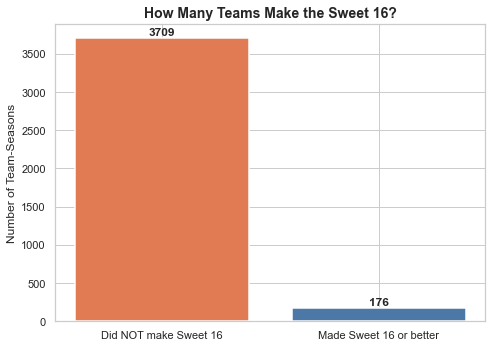

In [7]:
# Visualize the class split
fig, ax = plt.subplots(figsize=(7, 5))
counts = df['made_sweet16'].value_counts()
bars = ax.bar(['Did NOT make Sweet 16', 'Made Sweet 16 or better'],
              counts.values,
              color=['#e07b54', '#4c78a8'],
              edgecolor='white', linewidth=1.5)

# Add count labels on bars
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=12)

ax.set_title('How Many Teams Make the Sweet 16?', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Team-Seasons')
plt.tight_layout()
plt.show()

---
## 🔍 Step 4: Exploratory Data Analysis (EDA)

Before building a model, smart data scientists always **look at the data first**. This is called Exploratory Data Analysis (EDA).

The goal: understand which stats seem to separate Sweet 16 teams from the rest. This gives us intuition about what will matter to the model.

In [8]:
# Compare average stats between Sweet 16 teams and non-Sweet 16 teams
key_stats = ['W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D', 'TOR', 'TORD']

comparison = df.groupby('made_sweet16')[key_stats].mean().round(2)
comparison.index = ['Did NOT make Sweet 16', 'Made Sweet 16']
print("Average stats by outcome:")
comparison

Average stats by outcome:


,W,ADJOE,ADJDE,BARTHAG,EFG_O,EFG_D,TOR,TORD
Did NOT make Sweet 16,15.54,102.72,103.82,0.47,49.78,50.28,18.63,18.46
Made Sweet 16,27.45,116.48,93.33,0.91,53.14,46.97,16.80,18.89


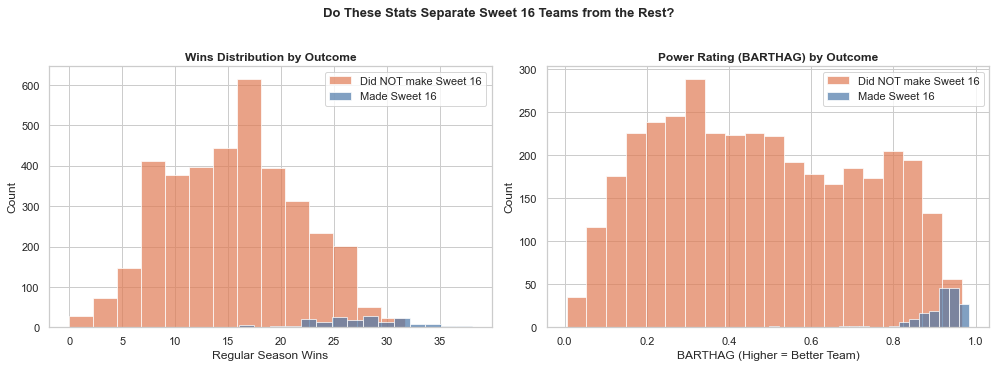


💡 Notice how Sweet 16 teams cluster at the high end of both charts!
This tells us these variables will probably be useful predictors.


In [9]:
# Visualize: Distribution of wins by outcome
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wins distribution
for outcome, color, label in zip([0, 1], ['#e07b54', '#4c78a8'],
                                  ['Did NOT make Sweet 16', 'Made Sweet 16']):
    subset = df[df['made_sweet16'] == outcome]['W']
    axes[0].hist(subset, bins=15, alpha=0.7, color=color, label=label, edgecolor='white')

axes[0].set_title('Wins Distribution by Outcome', fontweight='bold')
axes[0].set_xlabel('Regular Season Wins')
axes[0].set_ylabel('Count')
axes[0].legend()

# BARTHAG (Power Rating) distribution
for outcome, color, label in zip([0, 1], ['#e07b54', '#4c78a8'],
                                  ['Did NOT make Sweet 16', 'Made Sweet 16']):
    subset = df[df['made_sweet16'] == outcome]['BARTHAG']
    axes[1].hist(subset, bins=20, alpha=0.7, color=color, label=label, edgecolor='white')

axes[1].set_title('Power Rating (BARTHAG) by Outcome', fontweight='bold')
axes[1].set_xlabel('BARTHAG (Higher = Better Team)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Do These Stats Separate Sweet 16 Teams from the Rest?',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 Notice how Sweet 16 teams cluster at the high end of both charts!")
print("This tells us these variables will probably be useful predictors.")

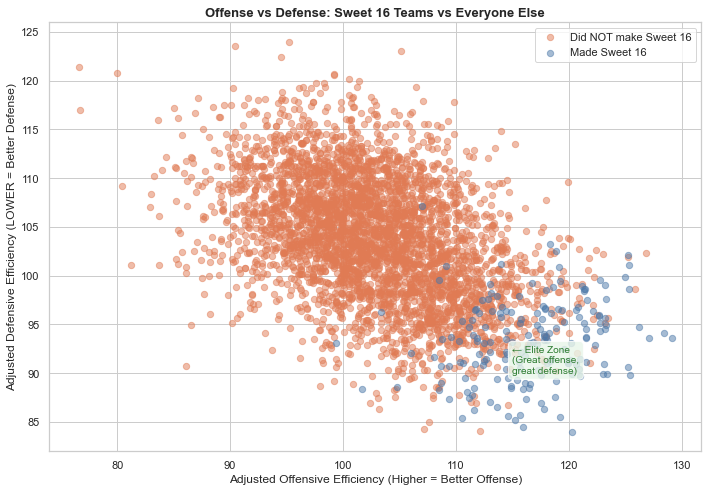


💡 Sweet 16 teams (blue) tend to be in the TOP-RIGHT and BOTTOM-RIGHT:
   High offense (right) AND low defense allowed (bottom)


In [10]:
# Scatterplot: Offense vs Defense — colored by outcome
fig, ax = plt.subplots(figsize=(10, 7))

for outcome, color, label, marker in zip(
        [0, 1], ['#e07b54', '#4c78a8'],
        ['Did NOT make Sweet 16', 'Made Sweet 16'],
        ['o', '★']):
    subset = df[df['made_sweet16'] == outcome]
    ax.scatter(subset['ADJOE'], subset['ADJDE'],
               color=color, label=label, alpha=0.5, s=40)

ax.set_xlabel('Adjusted Offensive Efficiency (Higher = Better Offense)', fontsize=12)
ax.set_ylabel('Adjusted Defensive Efficiency (LOWER = Better Defense)', fontsize=12)
ax.set_title('Offense vs Defense: Sweet 16 Teams vs Everyone Else', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)

# Add a reference box for the "elite" zone
ax.annotate('← Elite Zone\n(Great offense,\ngreat defense)',
            xy=(115, 90), fontsize=10, color='#2e7d32',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8f5e9', alpha=0.8))

plt.tight_layout()
plt.show()

print("\n💡 Sweet 16 teams (blue) tend to be in the TOP-RIGHT and BOTTOM-RIGHT:")
print("   High offense (right) AND low defense allowed (bottom)")

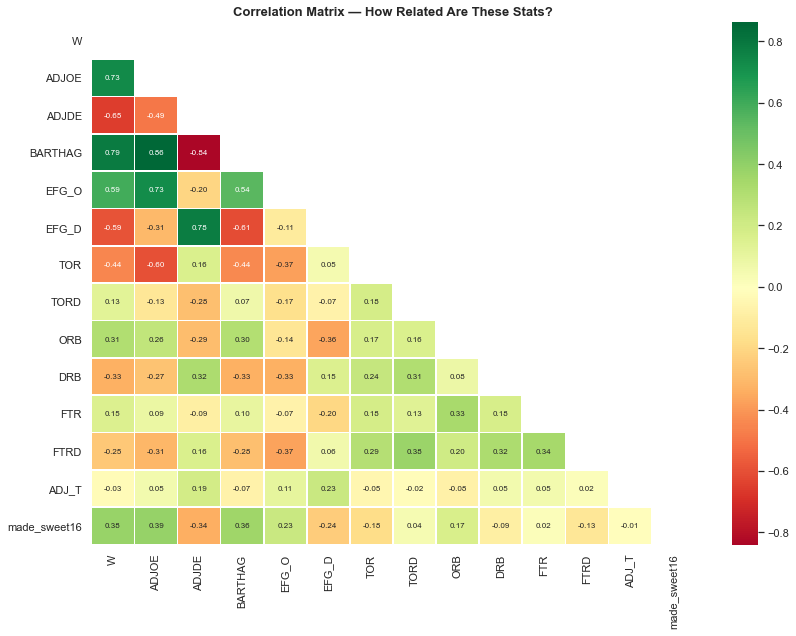


💡 Look at the bottom row (made_sweet16):
   Positive values (green) = higher stat → more likely to make Sweet 16
   Negative values (red) = lower stat → more likely to make Sweet 16
   BARTHAG (power rating) has the highest correlation with our target!


In [11]:
# Correlation heatmap — how related are the features to each other?
# (Important to understand before modeling)

numeric_cols = ['W', 'ADJOE', 'ADJDE', 'BARTHAG', 'EFG_O', 'EFG_D',
                'TOR', 'TORD', 'ORB', 'DRB', 'FTR', 'FTRD', 'ADJ_T', 'made_sweet16']

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # only show lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, ax=ax,
            linewidths=0.5, annot_kws={'size': 8})

ax.set_title('Correlation Matrix — How Related Are These Stats?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Look at the bottom row (made_sweet16):")
print("   Positive values (green) = higher stat → more likely to make Sweet 16")
print("   Negative values (red) = lower stat → more likely to make Sweet 16")
print("   BARTHAG (power rating) has the highest correlation with our target!")

---
## 🛠️ Step 5: Prepare the Data for Modeling

Before we can train a model, we need to:

1. **Select our features** (the inputs we'll give the model)
2. **Handle missing values** (some rows might have gaps)
3. **Split into train/test sets** (the most important concept in ML!)
4. **Scale the features** (so no one variable dominates just because of its units)

### 🔑 The Train/Test Split — The Most Important Idea in ML

Imagine studying for an exam using old practice tests. You learn from those (training), and then you're tested on a *new* exam you've never seen (testing). That's exactly what we do here:

- **Training set (80%)** — the model learns patterns from this
- **Test set (20%)** — we hide this from the model, then check how accurate its predictions are on data it's never seen

If we evaluated on the same data we trained on, it's like grading yourself on your own practice test — meaningless!

In [12]:
# Select features (inputs to the model)
features = [
    'ADJOE',    # Adjusted Offensive Efficiency
    'ADJDE',    # Adjusted Defensive Efficiency
    'BARTHAG',  # Power Rating
    'EFG_O',    # Effective Field Goal % (Offense)
    'EFG_D',    # Effective Field Goal % (Defense)
    'TOR',      # Turnover Rate
    'TORD',     # Opponent Turnover Rate
    'ORB',      # Offensive Rebound Rate
    'DRB',      # Defensive Rebound Rate
    'FTR',      # Free Throw Rate
    'FTRD',     # Opponent Free Throw Rate
    'ADJ_T',    # Adjusted Tempo
    'W',        # Regular Season Wins
]

target = 'made_sweet16'

# Drop rows with missing values in our feature set
model_df = df[features + [target]].dropna()
print(f"Rows available for modeling: {len(model_df)}")

X = model_df[features]
y = model_df[target]

# Split into train (80%) and test (20%)
# random_state=42 makes it reproducible (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set: {len(X_train)} rows")
print(f"Test set:     {len(X_test)} rows")
print(f"\nSweet 16 rate in training set: {y_train.mean():.1%}")
print(f"Sweet 16 rate in test set:     {y_test.mean():.1%}")
print("\n✅ The Sweet 16 rates are similar — our split is balanced!")

Rows available for modeling: 3885

Training set: 3108 rows
Test set:     777 rows

Sweet 16 rate in training set: 4.5%
Sweet 16 rate in test set:     4.5%

✅ The Sweet 16 rates are similar — our split is balanced!


In [13]:
# Scale the features
# This transforms all features to have mean=0 and std=1
# Think of it like converting temperatures: Fahrenheit → Celsius
# It ensures no one variable (like wins: 25) dominates another (like EFG: 0.52)
#
# IMPORTANT: We fit the scaler on training data ONLY, then apply to test data
# (If we fit on test data too, we'd be "peeking" at the test set!)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # only transform, don't re-fit!

print("✅ Features scaled successfully!")
print(f"\nExample: ADJOE before scaling: mean = {X_train['ADJOE'].mean():.1f}")
print(f"         ADJOE after scaling:  mean ≈ 0.00 (by design)")

✅ Features scaled successfully!

Example: ADJOE before scaling: mean = 103.4
         ADJOE after scaling:  mean ≈ 0.00 (by design)


---
## 🤖 Step 6: Model 1 — Logistic Regression

### What is Logistic Regression?

Despite the name, logistic regression is actually a **classification** model (not a regression model!). Here's the intuition:

Imagine drawing a line through the data that best separates Sweet 16 teams from non-Sweet 16 teams. Logistic regression finds that line — but instead of outputting "yes" or "no" directly, it outputs a **probability between 0 and 1**.

> "This team has a 73% chance of making the Sweet 16"

We then choose a cutoff (usually 50%): if probability > 50%, predict yes; otherwise, predict no.

**Why start here?**
- Simple and fast
- Easy to interpret (each feature gets a "weight")
- Works surprisingly well on many real problems
- This is one of the most common models in fintech credit risk! 🏦

In [14]:
# Train the Logistic Regression model
# max_iter=1000 just means "try hard enough to find the best fit"
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)  # ← this is where the learning happens!

# Make predictions on the test set
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]  # probability of Sweet 16

# Evaluate accuracy
lr_accuracy = accuracy_score(y_test, lr_preds)
print(f"✅ Logistic Regression trained!")
print(f"   Accuracy on test set: {lr_accuracy:.1%}")
print(f"\n   (Baseline: if we just predicted 'No' for everyone: {1 - y_test.mean():.1%})")
print(f"   Our model needs to beat that to be useful!")

✅ Logistic Regression trained!
   Accuracy on test set: 98.1%

   (Baseline: if we just predicted 'No' for everyone: 95.5%)
   Our model needs to beat that to be useful!


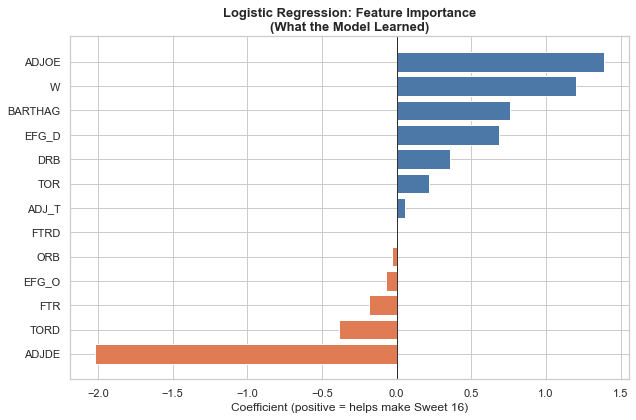


💡 Blue = more of this stat → more likely to make Sweet 16
   Red  = more of this stat → LESS likely to make Sweet 16

   Do these match your basketball intuition?


In [15]:
# What did the model learn? Let's look at feature coefficients
# Positive coefficient = higher value → more likely to be Sweet 16
# Negative coefficient = higher value → less likely to be Sweet 16

coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e07b54' if c < 0 else '#4c78a8' for c in coef_df['Coefficient']]
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='white')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = helps make Sweet 16)')
ax.set_title('Logistic Regression: Feature Importance\n(What the Model Learned)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Blue = more of this stat → more likely to make Sweet 16")
print("   Red  = more of this stat → LESS likely to make Sweet 16")
print("\n   Do these match your basketball intuition?")

Understanding the Confusion Matrix

A confusion matrix has 4 boxes:

                 PREDICTED: No  |  PREDICTED: Yes
ACTUAL: No    [True Negative]   |  [False Positive]  ← said yes, was wrong
ACTUAL: Yes   [False Negative]  |  [True Positive]   ← said yes, was right
                  ↑ said no, was wrong

We WANT big numbers on the diagonal (top-left, bottom-right).



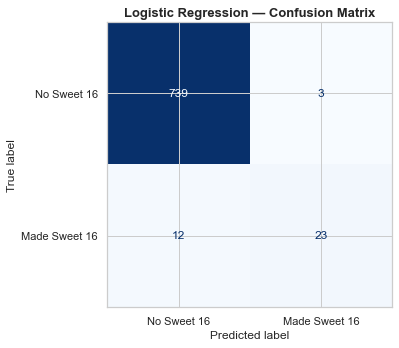


Detailed Report:
               precision    recall  f1-score   support

  No Sweet 16       0.98      1.00      0.99       742
Made Sweet 16       0.88      0.66      0.75        35

     accuracy                           0.98       777
    macro avg       0.93      0.83      0.87       777
 weighted avg       0.98      0.98      0.98       777



In [16]:
# Confusion Matrix — A more detailed look at accuracy
# This shows us WHERE the model makes mistakes

print("=" * 50)
print("Understanding the Confusion Matrix")
print("=" * 50)
print("""
A confusion matrix has 4 boxes:

                 PREDICTED: No  |  PREDICTED: Yes
ACTUAL: No    [True Negative]   |  [False Positive]  ← said yes, was wrong
ACTUAL: Yes   [False Negative]  |  [True Positive]   ← said yes, was right
                  ↑ said no, was wrong

We WANT big numbers on the diagonal (top-left, bottom-right).
""")

cm = confusion_matrix(y_test, lr_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['No Sweet 16', 'Made Sweet 16'])
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDetailed Report:")
print(classification_report(y_test, lr_preds,
                             target_names=['No Sweet 16', 'Made Sweet 16']))

### 📖 Understanding Precision, Recall, and F1-Score

**Accuracy** is the overall hit rate, but it can be misleading when classes are unbalanced (most teams don't make the Sweet 16). So we also look at:

- **Precision** — Of all teams I predicted would make Sweet 16, what fraction actually did? *("When I say yes, how often am I right?")*
- **Recall** — Of all teams that actually made Sweet 16, what fraction did I catch? *("How many of the real cases did I find?")*
- **F1-Score** — A single number that balances precision and recall

> 💡 **Fintech connection:** In credit default modeling, recall is critical — you'd rather flag too many risky loans than miss a defaulter. Getting this tradeoff right is a core part of building real-world financial models.

---
## 🌳 Step 7: Model 2 — Decision Tree

### What is a Decision Tree?

A decision tree works exactly like the name implies — it's a series of yes/no questions that lead to a prediction. Like a flowchart:

```
Is BARTHAG > 0.85?
  ├── Yes → Is ADJDE < 95?
  │           ├── Yes → Predict: SWEET 16 ✅
  │           └── No  → Is ADJOE > 115?
  │                       ├── Yes → Predict: SWEET 16 ✅
  │                       └── No  → Predict: OUT ❌
  └── No  → Predict: OUT ❌
```

**Why decision trees are great for teaching:**
- You can literally draw them and show anyone
- The rules are completely transparent
- Even non-technical people can follow the logic

**The tradeoff:** Trees can *overfit* — they can memorize the training data too well and fail on new data. We'll control this with `max_depth`.

In [17]:
# Train the Decision Tree
# max_depth limits how many levels deep the tree can grow
# Without a limit, the tree would memorize every training example (overfitting!)

dt_model = DecisionTreeClassifier(max_depth=4, random_state=42, min_samples_leaf=10)
dt_model.fit(X_train, y_train)  # Note: Decision trees don't need scaled features!

# Make predictions
dt_preds = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_preds)

print(f"✅ Decision Tree trained!")
print(f"   Accuracy on test set: {dt_accuracy:.1%}")

✅ Decision Tree trained!
   Accuracy on test set: 97.3%


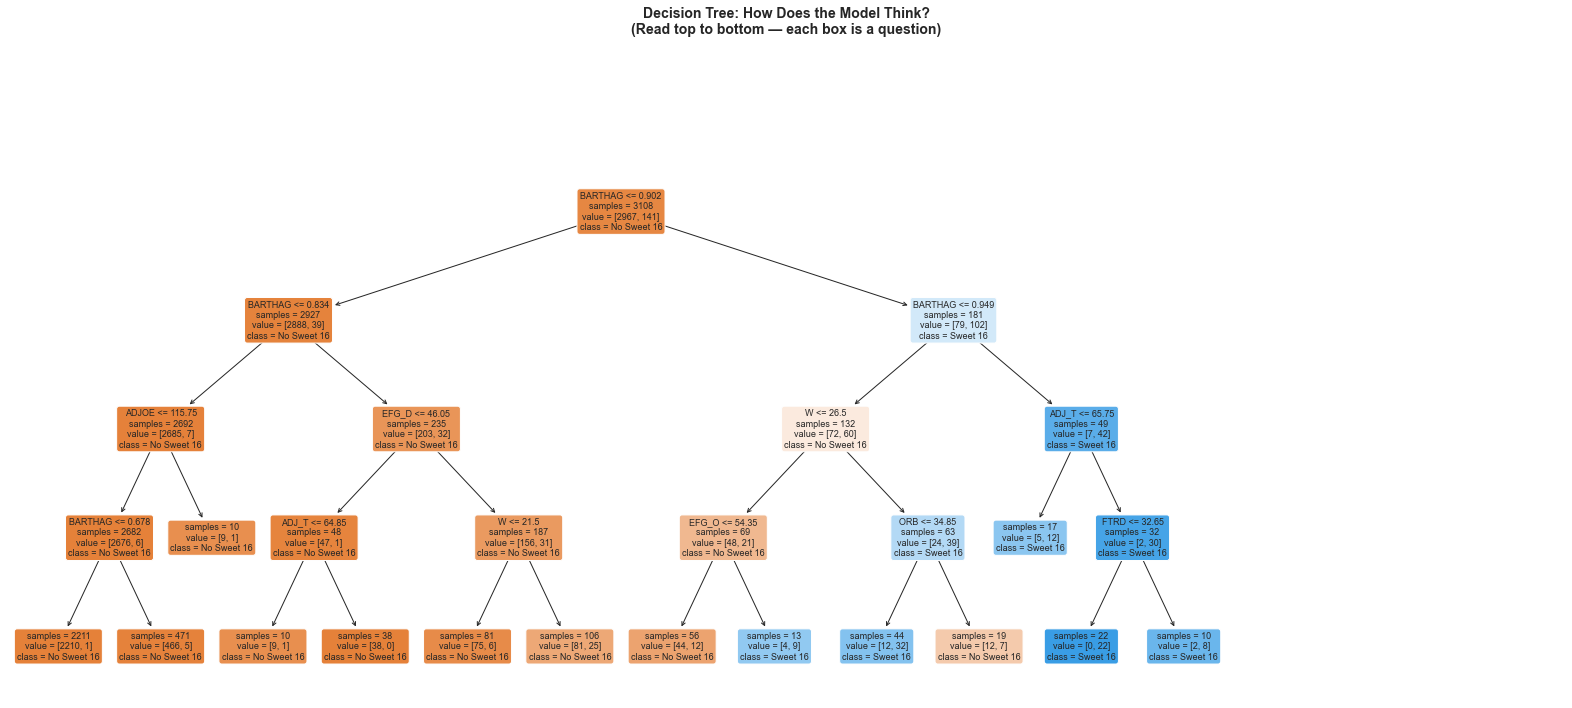


💡 Each box splits the data with a yes/no question about a stat.
   BLUE boxes = predicting Sweet 16 | ORANGE boxes = predicting out
   The deeper you go, the more specific the rules get.


In [18]:
# Visualize the Decision Tree — this is the best part!
fig, ax = plt.subplots(figsize=(22, 10))

plot_tree(
    dt_model,
    feature_names=features,
    class_names=['No Sweet 16', 'Sweet 16'],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=False,  # hide technical details
    proportion=False
)

ax.set_title('Decision Tree: How Does the Model Think?\n(Read top to bottom — each box is a question)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Each box splits the data with a yes/no question about a stat.")
print("   BLUE boxes = predicting Sweet 16 | ORANGE boxes = predicting out")
print("   The deeper you go, the more specific the rules get.")

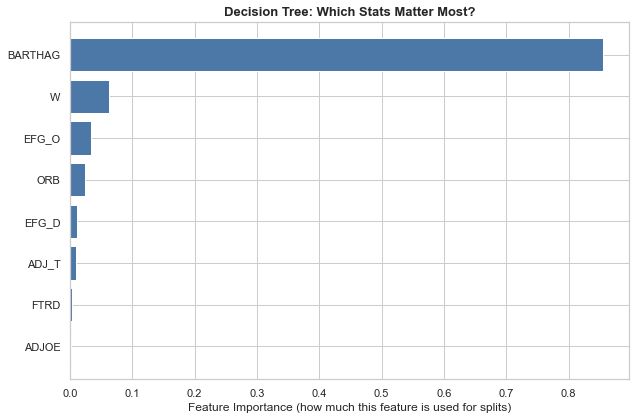

In [19]:
# Decision Tree Feature Importance
# Which features does the tree rely on the most?

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

importance_df = importance_df[importance_df['Importance'] > 0]  # only show used features

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(importance_df['Feature'], importance_df['Importance'],
        color='#4c78a8', edgecolor='white')
ax.set_xlabel('Feature Importance (how much this feature is used for splits)')
ax.set_title('Decision Tree: Which Stats Matter Most?', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

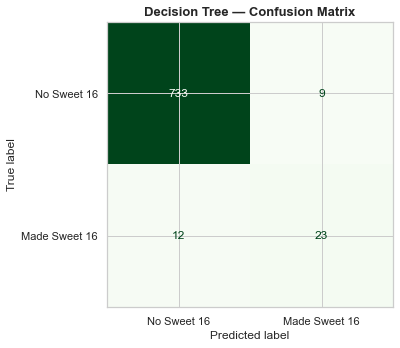


Detailed Report:
               precision    recall  f1-score   support

  No Sweet 16       0.98      0.99      0.99       742
Made Sweet 16       0.72      0.66      0.69        35

     accuracy                           0.97       777
    macro avg       0.85      0.82      0.84       777
 weighted avg       0.97      0.97      0.97       777



In [20]:
# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_preds)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt,
                                  display_labels=['No Sweet 16', 'Made Sweet 16'])
fig, ax = plt.subplots(figsize=(7, 5))
disp_dt.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Decision Tree — Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nDetailed Report:")
print(classification_report(y_test, dt_preds,
                             target_names=['No Sweet 16', 'Made Sweet 16']))

---
## ⚖️ Step 8: Compare the Two Models

Now let's put both models head-to-head and decide which one we'd actually want to use.

In [21]:
# Side-by-side comparison
from sklearn.metrics import precision_score, recall_score, f1_score

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree'],
    'Accuracy': [
        accuracy_score(y_test, lr_preds),
        accuracy_score(y_test, dt_preds)
    ],
    'Precision': [
        precision_score(y_test, lr_preds),
        precision_score(y_test, dt_preds)
    ],
    'Recall': [
        recall_score(y_test, lr_preds),
        recall_score(y_test, dt_preds)
    ],
    'F1-Score': [
        f1_score(y_test, lr_preds),
        f1_score(y_test, dt_preds)
    ]
})

results_display = results.set_index('Model')
results_display = results_display.applymap(lambda x: f"{x:.1%}")
print("Model Comparison:")
results_display

Model Comparison:


,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,98.1%,88.5%,65.7%,75.4%
Decision Tree,97.3%,71.9%,65.7%,68.7%


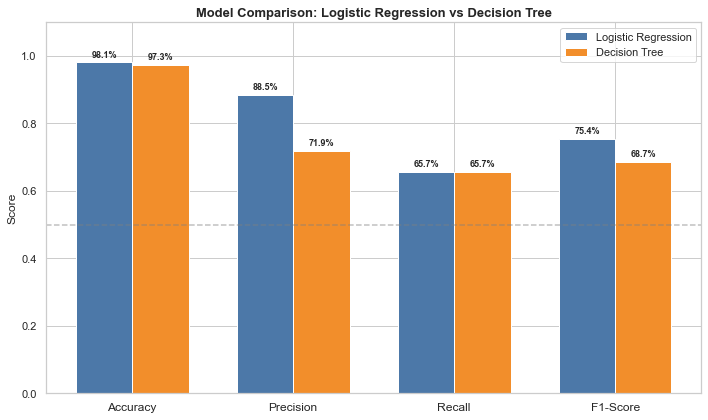

In [22]:
# Visual comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
lr_scores = [
    accuracy_score(y_test, lr_preds),
    precision_score(y_test, lr_preds),
    recall_score(y_test, lr_preds),
    f1_score(y_test, lr_preds)
]
dt_scores = [
    accuracy_score(y_test, dt_preds),
    precision_score(y_test, dt_preds),
    recall_score(y_test, dt_preds),
    f1_score(y_test, dt_preds)
]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, lr_scores, width, label='Logistic Regression',
               color='#4c78a8', edgecolor='white')
bars2 = ax.bar(x + width/2, dt_scores, width, label='Decision Tree',
               color='#f28e2b', edgecolor='white')

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_title('Model Comparison: Logistic Regression vs Decision Tree', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='50% baseline')

plt.tight_layout()
plt.show()

---
## 🎮 Step 9: Try It Yourself — Predict a Real Team!

Let's make this concrete. You can plug in a team's stats and see what the models predict.

We'll look up some real teams from the dataset and run them through both models.

In [24]:
# Find some interesting teams to test
# Let's grab a known powerhouse and an underdog from the dataset

# Show teams we can search
sample_teams = df[df['YEAR'].isin([2024]) & df['POSTSEASON'].notna()][
    ['TEAM', 'YEAR', 'W', 'BARTHAG', 'ADJOE', 'ADJDE', 'POSTSEASON', 'SEED']
].sort_values('BARTHAG', ascending=False).head(20)

print("Top 20 teams by power rating in 2024:")
sample_teams

Top 20 teams by power rating in 2019:


,TEAM,YEAR,W,BARTHAG,ADJOE,ADJDE,POSTSEASON,SEED
3523,Houston,2024,30,0.9785,119.2,85.5,S16,1.0
3524,Connecticut,2024,31,0.9712,127.1,93.6,Champions,1.0
3525,Purdue,2024,29,0.9644,126.2,94.7,2ND,1.0
3527,Iowa St.,2024,27,0.9583,113.6,86.5,S16,2.0
3535,Auburn,2024,27,0.9573,120.7,92.1,R64,4.0
3528,Arizona,2024,25,0.9526,121.5,93.6,S16,2.0
3529,Tennessee,2024,24,0.9382,115.6,91.2,E8,2.0
3530,Marquette,2024,25,0.9328,118.9,94.6,S16,2.0
3526,North Carolina,2024,27,0.9305,116.8,93.2,S16,1.0
3531,Creighton,2024,23,0.9289,120.6,96.5,S16,3.0


In [25]:
def predict_team(team_name, year):
    """Look up a team from the dataset and run both models on it."""
    
    # Find the team
    team_row = df[(df['TEAM'] == team_name) & (df['YEAR'] == year)]
    
    if len(team_row) == 0:
        print(f"Team '{team_name}' in {year} not found. Try another name.")
        return
    
    print(f"\n{'='*55}")
    print(f"  Team: {team_name} ({year})")
    print(f"  Wins: {team_row['W'].values[0]}  |  Power Rating: {team_row['BARTHAG'].values[0]:.3f}")
    print(f"  Actual result: {team_row['POSTSEASON'].values[0]}")
    print(f"  Actual Sweet 16: {'Yes ✅' if team_row['made_sweet16'].values[0] == 1 else 'No ❌'}")
    print(f"{'='*55}")
    
    team_features = team_row[features].values
    team_features_scaled = scaler.transform(team_features)
    
    # Logistic Regression
    lr_prob = lr_model.predict_proba(team_features_scaled)[0, 1]
    lr_pred = "Sweet 16 ✅" if lr_prob > 0.5 else "Out ❌"
    
    # Decision Tree
    dt_prob = dt_model.predict_proba(team_features)[0, 1]
    dt_pred = "Sweet 16 ✅" if dt_prob > 0.5 else "Out ❌"
    
    print(f"  Logistic Regression: {lr_pred}  (confidence: {lr_prob:.1%})")
    print(f"  Decision Tree:       {dt_pred}  (confidence: {dt_prob:.1%})")
    print()


# Try some teams!
predict_team('Duke', 2019)
predict_team('Gonzaga', 2019)
predict_team('Virginia', 2019)  # 2019 National Champions
predict_team('UC Irvine', 2019)  # Famous 2019 upset team


  Team: Duke (2019)
  Wins: 32  |  Power Rating: 0.965
  Actual result: E8
  Actual Sweet 16: Yes ✅
  Logistic Regression: Sweet 16 ✅  (confidence: 93.0%)
  Decision Tree:       Sweet 16 ✅  (confidence: 100.0%)


  Team: Gonzaga (2019)
  Wins: 33  |  Power Rating: 0.974
  Actual result: E8
  Actual Sweet 16: Yes ✅
  Logistic Regression: Sweet 16 ✅  (confidence: 92.8%)
  Decision Tree:       Sweet 16 ✅  (confidence: 100.0%)


  Team: Virginia (2019)
  Wins: 35  |  Power Rating: 0.974
  Actual result: Champions
  Actual Sweet 16: Yes ✅
  Logistic Regression: Sweet 16 ✅  (confidence: 95.9%)
  Decision Tree:       Sweet 16 ✅  (confidence: 70.6%)


  Team: UC Irvine (2019)
  Wins: 31  |  Power Rating: 0.746
  Actual result: R32
  Actual Sweet 16: No ❌
  Logistic Regression: Out ❌  (confidence: 4.5%)
  Decision Tree:       Out ❌  (confidence: 1.1%)



In [26]:
# ✏️ YOUR TURN! Try your favorite team:
predict_team('BYU', 2024)   # ← Change this to any team you want!

# To find available team names:
# df[df['YEAR'] == 2019]['TEAM'].sort_values().tolist()


  Team: BYU (2024)
  Wins: 23  |  Power Rating: 0.907
  Actual result: R64
  Actual Sweet 16: No ❌
  Logistic Regression: Out ❌  (confidence: 21.6%)
  Decision Tree:       Sweet 16 ✅  (confidence: 69.2%)



---
## 🧠 Step 10: Key Concepts Recap & The Bridge to Fintech

You've now built two real machine learning models! Let's connect what you learned to the world of fintech and credit risk.

### What you just did — and what it maps to in fintech:

| Basketball Tutorial | Credit Default Modeling |
|---------------------|------------------------|
| Team's season stats (ADJOE, BARTHAG, wins...) | Borrower's financial profile (income, credit score, debt ratio...) |
| Target: Did they make Sweet 16? (0/1) | Target: Did they default? (0/1) |
| Logistic Regression model | Same model — industry standard in credit risk |
| Decision Tree | Used for explainability in regulated industries |
| Precision (when we say Sweet 16, how often right?) | Precision (when we flag a defaulter, how often right?) |
| Recall (how many Sweet 16 teams did we catch?) | Recall (how many actual defaulters did we catch?) |
| Train/test split | Same — critical to prevent overfitting |

### The most important ideas to take away:

1. **Supervised learning** = show the model examples with known answers → it learns patterns → it predicts new cases
2. **Train/test split** = you must evaluate on data the model has NEVER seen
3. **Accuracy alone isn't enough** — precision and recall tell you about errors in each direction
4. **Interpretability matters** — in regulated industries (banking), you need to explain WHY the model said no
5. **Garbage in, garbage out** — the data quality and feature selection matter more than the model choice

---

## 🚀 What's Next?

Now that you understand the fundamentals, next we'll apply these exact same techniques to a real fintech dataset of consumer loans to predict **credit default**. Same tools, same workflow — real stakes.

Some questions to think about before then:
- What features might predict whether someone defaults on a loan?
- Would you rather minimize false positives or false negatives? Why does it matter for a bank?
- What happens if your model is biased against certain groups of people?

---
*Dataset: [College Basketball Dataset by Andrew Sundberg](https://www.kaggle.com/datasets/andrewsundberg/college-basketball-dataset) — Kaggle (free download)*

*Libraries used: pandas, numpy, matplotlib, seaborn, scikit-learn*